# Systematic Risk Parameter Sweep
**Docker image**: `ml4t`

## Purpose
Calibrate position-level exit rules (StopLoss, TakeProfit, TrailingStop) by
sweeping the parameter space rather than hand-picking three or four configs.
1D sweeps reveal each rule's sensitivity curve; 2D grids map joint behaviour;
MAE/MFE percentiles turn realized excursions into a data-driven prior. The
whole point is that a generic preference for "tighter exits" is a worse
selection rule than calibration.

## Learning Objectives
After completing this notebook, you will be able to:
- Run 1D sweeps of StopLoss, TakeProfit, and TrailingStop and read the elbow.
- Build SL×TP and SL×Trail heatmaps to expose joint rule interactions.
- Use `MAEMFEAnalyzer.suggest_stop_loss / suggest_take_profit` to calibrate stops from realized trade paths.
- Compare grid-optimal vs MAE/MFE-calibrated configurations under one ranked Calmar table.

## Book reference
§19.7 Adaptive Risk Controls — Figures 19.6 (1D sweeps) and 19.7 (joint SL×TP surface).

## Prerequisites
Complete [`02_exit_strategies`](02_exit_strategies.ipynb) and
[`03_position_sizing_mae_mfe`](03_position_sizing_mae_mfe.ipynb) first;
[`10_ml4t_backtest_risk_demo`](10_ml4t_backtest_risk_demo.ipynb) is the rule-API reference.

In [1]:
"""Systematic Risk Parameter Sweep."""

import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
from matplotlib import pyplot as plt
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

from ml4t.backtest import (
    BacktestConfig,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.analytics.trades import MAEMFEAnalyzer, TradeAnalyzer
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor
from ml4t.backtest.risk.position import RuleChain, StopLoss, TakeProfit, TrailingStop

from data import load_etfs
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
# Data parameters --- override these for different assets
N_ASSETS = 5
N_BARS = 1260  # 5 years of daily bars
INITIAL_CASH = 100_000
CADENCE_DAYS = 21
SEED = 42
OUTPUT_DIR = get_output_dir(19, "risk_sweep")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
set_global_seeds(SEED)

## Setup: Real Multi-Asset ETF Panel

We use a five-ETF panel (SPY, QQQ, IWM, XLF, EEM) over 2019–2023 to expose
the calibration mechanics on real cross-sectional dispersion: broad equities,
tech, small-cap, financials, and emerging markets carry genuinely different
volatility and drawdown profiles. The same patterns flow into the ETF case
study (`strategy/risk_management.py`); this notebook is the parameter-search
layer that informs those production settings.

In [4]:
SYMBOLS = ["SPY", "QQQ", "IWM", "XLF", "EEM"]
prices_df = load_etfs(symbols=SYMBOLS, start_date="2019-01-02", end_date="2023-12-31").sort(
    ["symbol", "timestamp"]
)

# Slice each symbol to N_BARS so the sweep window matches the parameters cell
prices_df = (
    prices_df.with_columns(_bar=pl.col("timestamp").cum_count().over("symbol"))
    .filter(pl.col("_bar") <= N_BARS)
    .drop("_bar")
)

dates = prices_df.filter(pl.col("symbol") == SYMBOLS[0]).sort("timestamp")["timestamp"]

Build momentum weights from real trailing returns: at each rebalance date,
pick the top three ETFs by 60-day return and equal-weight them. This is the
same family of signal as the ETF case study, scoped down to a five-name
universe so the sweep stays cheap.

In [5]:
def build_momentum_weights(prices: pl.DataFrame, lookback: int, cadence: int) -> dict:
    """Top-3 equal-weight momentum at each rebalance date."""

    mom = (
        prices.sort(["symbol", "timestamp"])
        .with_columns(mom=(pl.col("close") / pl.col("close").shift(lookback) - 1).over("symbol"))
        .select("timestamp", "symbol", "mom")
        .drop_nulls()
    )
    rebalance_dates = dates.gather_every(cadence).to_list()
    weight_dict: dict = {}
    for ts in rebalance_dates:
        snap = mom.filter(pl.col("timestamp") == ts).sort("mom", descending=True)
        if snap.height == 0:
            continue
        picks = snap.head(3)["symbol"].to_list()
        weight_dict[ts] = {s: 1.0 / len(picks) for s in picks}
    return weight_dict


weight_dict = build_momentum_weights(prices_df, lookback=60, cadence=CADENCE_DAYS)
rebalance_dates = list(weight_dict.keys())

print(f"Loaded {len(prices_df):,} price bars for {N_ASSETS} ETFs")
print(f"Rebalance dates: {len(rebalance_dates)}, cadence: {CADENCE_DAYS} days")

Loaded 6,290 price bars for 5 ETFs
Rebalance dates: 57, cadence: 21 days


**Interpretation**: The five-ETF panel carries genuine volatility dispersion
(QQQ and IWM run hotter than XLF and EEM during 2020 and 2022), which is
enough to expose the calibration trade-offs the stop and target sweeps probe.

## 1. Sweep Runner

The `run_risk_sweep()` function is the core utility: given prices, weights,
a config, and a set of position rules, it runs a full Engine backtest and
returns a metrics dictionary. All sweep sections below call this function.

Rebalancing can fail when an asset drops out of the current bar snapshot, so this
helper closes stale positions before handing control back to the executor.

In [6]:
ANN_FACTOR = np.sqrt(252)


def _safe_execute(executor, targets, data, broker):
    """Handle missing assets gracefully during rebalancing.

    Closes any open position whose asset is no longer in the current bar's
    `data` snapshot, then hands the remaining targets to the executor. The
    only expected failure mode is `KeyError` from the executor when an
    asset *requested* in `targets` is itself absent from `data` — this
    happens transiently when a weight series is fixed pre-trade and the
    market data for that bar is incomplete. We skip that asset's rebalance
    for the bar; `TypeError` and other exceptions surface so real bugs are
    visible.
    """
    for pos in list(broker.positions.values()):
        if pos.asset not in data and pos.quantity != 0:
            broker.submit_order(pos.asset, -pos.quantity)
    try:
        executor.execute(targets, data, broker)
    except KeyError:
        # Requested asset absent from this bar's snapshot — skip its rebalance.
        pass

The strategy wrapper applies the chosen rule chain and rebalances on the requested cadence.

In [7]:
class SweepStrategy(Strategy):
    """Strategy for parameter sweep: applies rules and rebalances."""

    def __init__(self, weight_dict, rules=None, cadence_days=21):
        self.cadence_days = cadence_days
        self.last_rebalance = None
        self.rules = rules
        self.executor = TargetWeightExecutor(
            config=RebalanceConfig(
                min_trade_value=100.0,
                min_weight_change=0.005,
                allow_fractional=True,
            )
        )
        self._weights = weight_dict

    def on_start(self, broker):
        if self.rules is not None:
            broker.set_position_rules(self.rules)

    def on_data(self, timestamp, data, context, broker):
        if self.last_rebalance and (timestamp - self.last_rebalance).days < self.cadence_days:
            return
        self.last_rebalance = timestamp
        if timestamp in self._weights:
            targets = {a: w for a, w in self._weights[timestamp].items() if a in data}
            if targets:
                _safe_execute(self.executor, targets, data, broker)

The sweep runner executes one backtest configuration and returns the metrics used
throughout the one-dimensional and two-dimensional search surfaces.

In [8]:
def run_risk_sweep(
    prices,
    weight_dict,
    rules=None,
    initial_cash=100_000,
    commission_rate=0.001,
    slippage_rate=0.001,
    cadence_days=21,
):
    """Run one backtest configuration and return the metrics used by the sweep plots."""
    config = BacktestConfig(
        initial_cash=initial_cash,
        commission_rate=commission_rate,
        slippage_rate=slippage_rate,
        execution_mode=ExecutionMode.NEXT_BAR,
    )

    feed = DataFeed(prices_df=prices)
    strategy = SweepStrategy(weight_dict, rules=rules, cadence_days=cadence_days)
    engine = Engine(feed=feed, strategy=strategy, config=config)
    result = engine.run()

    sharpe = result.metrics.get("sharpe", 0.0)
    total_ret = result.equity.total_return
    max_dd = result.equity.max_dd
    calmar = abs(total_ret / max_dd) if max_dd != 0 else 0.0
    n_trades = len(result.trades)
    analyzer = TradeAnalyzer(result.trades) if result.trades else None
    win_rate = analyzer.win_rate if analyzer else 0.0
    return dict(
        sharpe=float(sharpe),
        max_dd=float(max_dd),
        calmar=float(calmar),
        total_return=float(total_ret),
        n_trades=n_trades,
        win_rate=float(win_rate),
        trades=result.trades,
    )

In [9]:
# Run baseline (no rules)
baseline = run_risk_sweep(
    prices_df,
    weight_dict,
    rules=None,
    initial_cash=INITIAL_CASH,
    cadence_days=CADENCE_DAYS,
)
print(
    f"Baseline: Sharpe={baseline['sharpe']:.3f}  MaxDD={baseline['max_dd']:.2%}  "
    f"Calmar={baseline['calmar']:.2f}  Trades={baseline['n_trades']}"
)

Baseline: Sharpe=0.585  MaxDD=-34.56%  Calmar=2.03  Trades=8


**Interpretation**: The baseline is the reference point for every sweep. A rule only
earns its complexity if it improves drawdown-adjusted performance relative to this line.

## 2. One-Dimensional Sweeps

Sweep each rule type independently to understand its individual effect.
For each parameter value we plot Sharpe and trade count vs the parameter.

In [10]:
# StopLoss sweep: 2% to 20%
sl_levels = [0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.10, 0.12, 0.15, 0.20]
sl_results = []
for pct in sl_levels:
    rules = RuleChain([StopLoss(pct=pct)])
    m = run_risk_sweep(
        prices_df,
        weight_dict,
        rules=rules,
        initial_cash=INITIAL_CASH,
        cadence_days=CADENCE_DAYS,
    )
    m["param"] = pct
    sl_results.append(m)
    print(f"  SL={pct:.0%}: Sharpe={m['sharpe']:.3f}  MaxDD={m['max_dd']:.2%}")

  SL=2%: Sharpe=0.384  MaxDD=-20.72%
  SL=3%: Sharpe=0.290  MaxDD=-22.12%
  SL=4%: Sharpe=0.245  MaxDD=-22.73%


  SL=5%: Sharpe=0.201  MaxDD=-23.23%
  SL=6%: Sharpe=0.379  MaxDD=-24.90%


  SL=8%: Sharpe=0.304  MaxDD=-27.57%


  SL=10%: Sharpe=0.269  MaxDD=-28.11%
  SL=12%: Sharpe=0.471  MaxDD=-26.85%
  SL=15%: Sharpe=0.501  MaxDD=-28.23%


  SL=20%: Sharpe=0.429  MaxDD=-30.95%


**Interpretation**: The stop-loss sweep isolates how quickly tighter protection
turns into whipsaw rather than true downside control.

In [11]:
# TakeProfit sweep: 3% to 30%
tp_levels = [0.03, 0.05, 0.07, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30]
tp_results = []
for pct in tp_levels:
    rules = RuleChain([TakeProfit(pct=pct)])
    m = run_risk_sweep(
        prices_df,
        weight_dict,
        rules=rules,
        initial_cash=INITIAL_CASH,
        cadence_days=CADENCE_DAYS,
    )
    m["param"] = pct
    tp_results.append(m)
    print(f"  TP={pct:.0%}: Sharpe={m['sharpe']:.3f}  MaxDD={m['max_dd']:.2%}")

  TP=3%: Sharpe=0.783  MaxDD=-2.45%


  TP=5%: Sharpe=0.564  MaxDD=-8.65%


  TP=7%: Sharpe=0.482  MaxDD=-19.16%
  TP=10%: Sharpe=0.399  MaxDD=-29.03%
  TP=12%: Sharpe=0.457  MaxDD=-28.97%


  TP=15%: Sharpe=0.561  MaxDD=-28.99%


  TP=20%: Sharpe=0.530  MaxDD=-25.30%


  TP=25%: Sharpe=0.509  MaxDD=-29.05%


  TP=30%: Sharpe=0.515  MaxDD=-34.56%


**Interpretation**: The take-profit sweep shows how much upside is lost when profits
are harvested too early.

In [12]:
# TrailingStop sweep: 2% to 15%
ts_levels = [0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.10, 0.12, 0.15]
ts_results = []
for pct in ts_levels:
    rules = RuleChain([TrailingStop(pct=pct)])
    m = run_risk_sweep(
        prices_df,
        weight_dict,
        rules=rules,
        initial_cash=INITIAL_CASH,
        cadence_days=CADENCE_DAYS,
    )
    m["param"] = pct
    ts_results.append(m)
    print(f"  Trail={pct:.0%}: Sharpe={m['sharpe']:.3f}  MaxDD={m['max_dd']:.2%}")

  Trail=2%: Sharpe=0.380  MaxDD=-3.15%
  Trail=3%: Sharpe=0.612  MaxDD=-4.01%


  Trail=4%: Sharpe=0.591  MaxDD=-6.32%
  Trail=5%: Sharpe=0.469  MaxDD=-8.30%


  Trail=6%: Sharpe=0.616  MaxDD=-7.58%


  Trail=8%: Sharpe=0.594  MaxDD=-9.39%


  Trail=10%: Sharpe=0.755  MaxDD=-11.82%


  Trail=12%: Sharpe=0.764  MaxDD=-13.33%
  Trail=15%: Sharpe=0.649  MaxDD=-16.79%


**Interpretation**: Trailing stops reveal whether the strategy benefits from dynamic
exits that follow winners instead of imposing a fixed cap on gains.

This plotting helper keeps the three sweep panels structurally identical and avoids one oversized visualization cell.

In [13]:
def add_sweep_panel(fig, col: int, sweep_data: list[dict], sweep_name: str, color: str) -> None:
    params = [d["param"] for d in sweep_data]
    sharpes = [d["sharpe"] for d in sweep_data]
    n_trades = [d["n_trades"] for d in sweep_data]
    fig.add_trace(
        go.Scatter(
            x=[f"{p:.0%}" for p in params],
            y=sharpes,
            mode="lines+markers",
            name=f"{sweep_name} Sharpe",
            line=dict(color=color),
            marker=dict(size=8),
        ),
        row=1,
        col=col,
        secondary_y=False,
    )
    fig.add_trace(
        go.Scatter(
            x=[f"{p:.0%}" for p in params],
            y=n_trades,
            mode="lines+markers",
            name=f"{sweep_name} Trades",
            line=dict(color=color, dash="dot"),
            marker=dict(size=6, symbol="square"),
            opacity=0.6,
        ),
        row=1,
        col=col,
        secondary_y=True,
    )
    fig.add_hline(
        y=baseline["sharpe"],
        line_dash="dash",
        line_color="gray",
        annotation_text="Baseline",
        row=1,
        col=col,
        secondary_y=False,
    )

In [14]:
# Visualize 1D sweeps
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=["StopLoss Sweep", "TakeProfit Sweep", "TrailingStop Sweep"],
    specs=[[{"secondary_y": True}] * 3],
)

for col, (sweep_data, sweep_name, color) in enumerate(
    [
        (sl_results, "StopLoss", "#1f77b4"),
        (tp_results, "TakeProfit", "#2ca02c"),
        (ts_results, "TrailingStop", "#ff7f0e"),
    ],
    start=1,
):
    add_sweep_panel(fig, col, sweep_data, sweep_name, color)

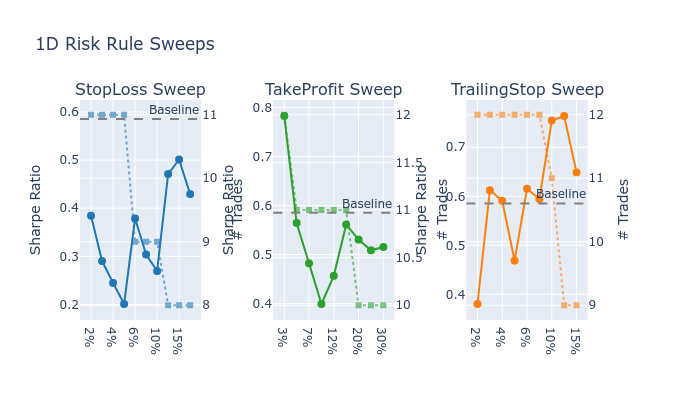

In [15]:
fig.update_yaxes(title_text="Sharpe Ratio", secondary_y=False)
fig.update_yaxes(title_text="# Trades", secondary_y=True)
fig.update_layout(height=400, title="1D Risk Rule Sweeps", showlegend=False)
fig.show()

**Interpretation**: The interactive sweep highlights the elbow region where more
protection starts costing too much in Sharpe and trade count.

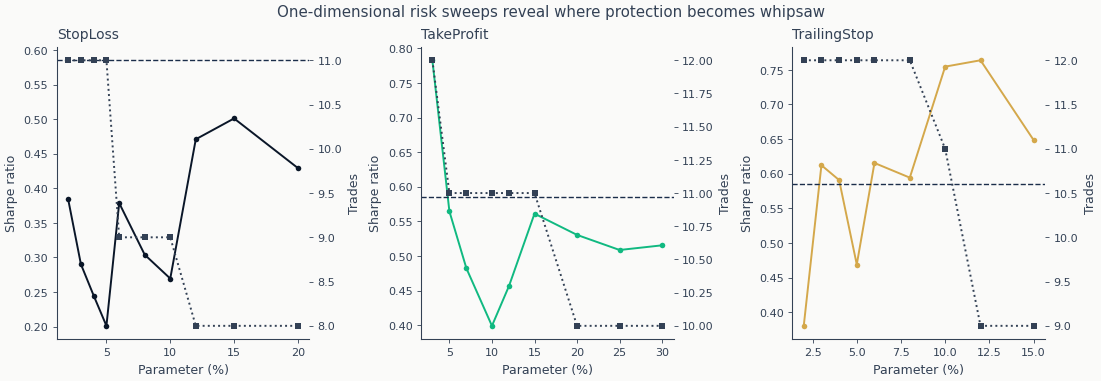

In [16]:
fig_sweep, axes = plt.subplots(1, 3, figsize=(11, 3.8), constrained_layout=True)
for ax, sweep_data, sweep_name, color in zip(
    axes,
    [sl_results, tp_results, ts_results],
    ["StopLoss", "TakeProfit", "TrailingStop"],
    [COLORS["blue"], COLORS["positive"], COLORS["amber"]],
    strict=False,
):
    params = np.array([d["param"] for d in sweep_data]) * 100
    sharpes = [d["sharpe"] for d in sweep_data]
    trades = [d["n_trades"] for d in sweep_data]
    ax.plot(params, sharpes, color=color, marker="o")
    ax.axhline(baseline["sharpe"], color=COLORS["slate"], linestyle="--", linewidth=1.0)
    ax.set_title(sweep_name)
    ax.set_xlabel("Parameter (%)")
    ax.set_ylabel("Sharpe ratio")
    ax2 = ax.twinx()
    ax2.plot(params, trades, color=COLORS["neutral"], marker="s", linestyle=":")
    ax2.set_ylabel("Trades")
fig_sweep.suptitle("One-dimensional risk sweeps reveal where protection becomes whipsaw")
plt.show()

# Persist 1D sweep data + baseline for the figure-19.6 publication script.
sweep_rows_1d = []
for sweep_data, sweep_name in (
    (sl_results, "StopLoss"),
    (tp_results, "TakeProfit"),
    (ts_results, "TrailingStop"),
):
    for d in sweep_data:
        sweep_rows_1d.append(
            {
                "rule": sweep_name,
                "param": float(d["param"]),
                "sharpe": float(d["sharpe"]),
                "n_trades": int(d["n_trades"]),
            }
        )
pl.DataFrame(sweep_rows_1d).write_parquet(OUTPUT_DIR / "risk_rule_1d_sweeps.parquet")
pl.DataFrame(
    [{"sharpe": float(baseline["sharpe"]), "n_trades": int(baseline["n_trades"])}]
).write_parquet(OUTPUT_DIR / "risk_rule_baseline.parquet")

**Interpretation**: The 1D sweeps reveal each rule's impact in isolation.
Tight stops (2-3%) typically hurt Sharpe by whipsawing out of positions
prematurely. Wider stops (8-15%) have less impact on Sharpe but provide
meaningful drawdown protection during tail events. TakeProfit and TrailingStop
show similar patterns --- overly aggressive targets sacrifice upside.

## 3. Two-Dimensional Heatmaps

Now we combine rules in 2D grids: StopLoss x TakeProfit and StopLoss x
TrailingStop. Heatmaps visualize Sharpe and Calmar across the full
parameter space.

In [17]:
# StopLoss x TakeProfit grid (5x5)
sl_grid = [0.03, 0.05, 0.08, 0.10, 0.15]
tp_grid = [0.05, 0.10, 0.15, 0.20, 0.30]

sl_tp_sharpe = np.zeros((len(sl_grid), len(tp_grid)))
sl_tp_calmar = np.zeros((len(sl_grid), len(tp_grid)))

print("Running SL x TP grid (25 combinations)...")
for i, sl in enumerate(sl_grid):
    for j, tp in enumerate(tp_grid):
        rules = RuleChain([StopLoss(pct=sl), TakeProfit(pct=tp)])
        m = run_risk_sweep(
            prices_df,
            weight_dict,
            rules=rules,
            initial_cash=INITIAL_CASH,
            cadence_days=CADENCE_DAYS,
        )
        sl_tp_sharpe[i, j] = m["sharpe"]
        sl_tp_calmar[i, j] = m["calmar"]
        print(f"  SL={sl:.0%} TP={tp:.0%}: Sharpe={m['sharpe']:.3f}  Calmar={m['calmar']:.2f}")

Running SL x TP grid (25 combinations)...
  SL=3% TP=5%: Sharpe=0.618  Calmar=2.74
  SL=3% TP=10%: Sharpe=0.905  Calmar=3.22
  SL=3% TP=15%: Sharpe=1.127  Calmar=5.49
  SL=3% TP=20%: Sharpe=0.637  Calmar=1.73
  SL=3% TP=30%: Sharpe=0.322  Calmar=0.60
  SL=5% TP=5%: Sharpe=0.364  Calmar=1.43
  SL=5% TP=10%: Sharpe=0.665  Calmar=2.02


  SL=5% TP=15%: Sharpe=0.929  Calmar=3.73
  SL=5% TP=20%: Sharpe=0.547  Calmar=1.46
  SL=5% TP=30%: Sharpe=0.224  Calmar=0.38
  SL=8% TP=5%: Sharpe=0.674  Calmar=3.61
  SL=8% TP=10%: Sharpe=0.571  Calmar=1.59
  SL=8% TP=15%: Sharpe=0.828  Calmar=3.12
  SL=8% TP=20%: Sharpe=0.505  Calmar=1.35


  SL=8% TP=30%: Sharpe=0.233  Calmar=0.39
  SL=10% TP=5%: Sharpe=0.614  Calmar=2.90
  SL=10% TP=10%: Sharpe=0.481  Calmar=1.13
  SL=10% TP=15%: Sharpe=0.752  Calmar=2.39
  SL=10% TP=20%: Sharpe=0.471  Calmar=1.24
  SL=10% TP=30%: Sharpe=0.179  Calmar=0.26
  SL=15% TP=5%: Sharpe=0.505  Calmar=1.79


  SL=15% TP=10%: Sharpe=0.255  Calmar=0.42
  SL=15% TP=15%: Sharpe=0.554  Calmar=1.25
  SL=15% TP=20%: Sharpe=0.325  Calmar=0.74
  SL=15% TP=30%: Sharpe=0.400  Calmar=0.90


**Interpretation**: The SL x TP grid tests whether the best stop depends on the
profit target instead of behaving like an independent control.

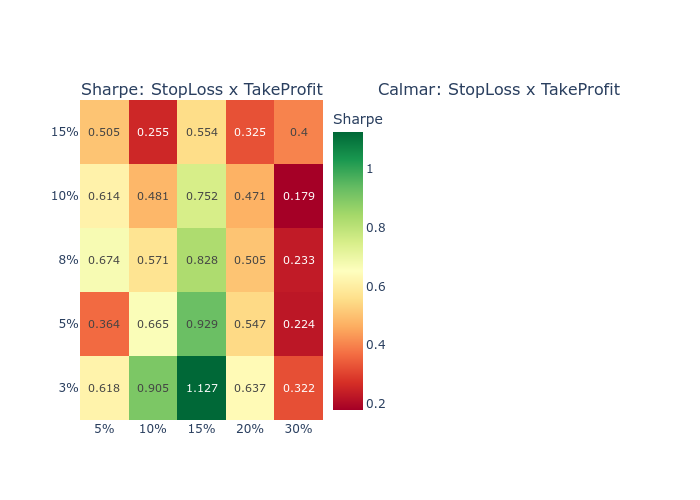

In [18]:
# Visualize SL x TP heatmaps
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Sharpe: StopLoss x TakeProfit", "Calmar: StopLoss x TakeProfit"],
)

sl_labels = [f"{x:.0%}" for x in sl_grid]
tp_labels = [f"{x:.0%}" for x in tp_grid]

fig.add_trace(
    go.Heatmap(
        z=sl_tp_sharpe,
        x=tp_labels,
        y=sl_labels,
        colorscale="RdYlGn",
        text=np.round(sl_tp_sharpe, 3),
        texttemplate="%{text}",
        textfont=dict(size=11),
        showscale=True,
        colorbar=dict(title="Sharpe", x=0.45),
    ),
    row=1,
    col=1,
)

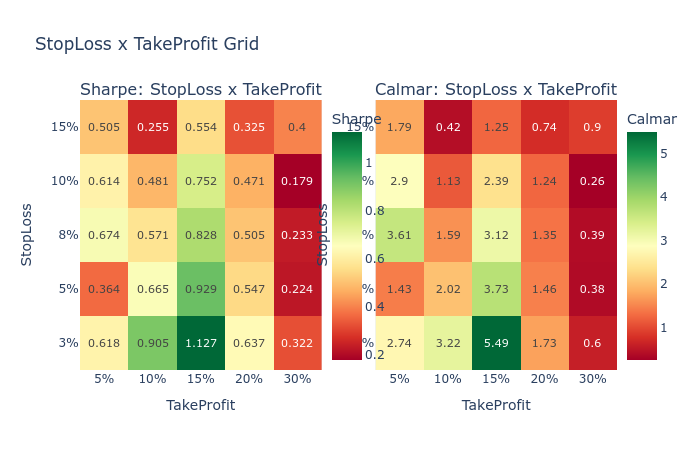

In [19]:
fig.add_trace(
    go.Heatmap(
        z=sl_tp_calmar,
        x=tp_labels,
        y=sl_labels,
        colorscale="RdYlGn",
        text=np.round(sl_tp_calmar, 2),
        texttemplate="%{text}",
        textfont=dict(size=11),
        showscale=True,
        colorbar=dict(title="Calmar", x=1.0),
    ),
    row=1,
    col=2,
)

fig.update_xaxes(title_text="TakeProfit", row=1, col=1)
fig.update_xaxes(title_text="TakeProfit", row=1, col=2)
fig.update_yaxes(title_text="StopLoss", row=1, col=1)
fig.update_yaxes(title_text="StopLoss", row=1, col=2)
fig.update_layout(height=450, title="StopLoss x TakeProfit Grid")
fig.show()

**Interpretation**: The heatmaps expose the stable region rather than a single best
point. Broad green zones are more trustworthy than isolated maxima.

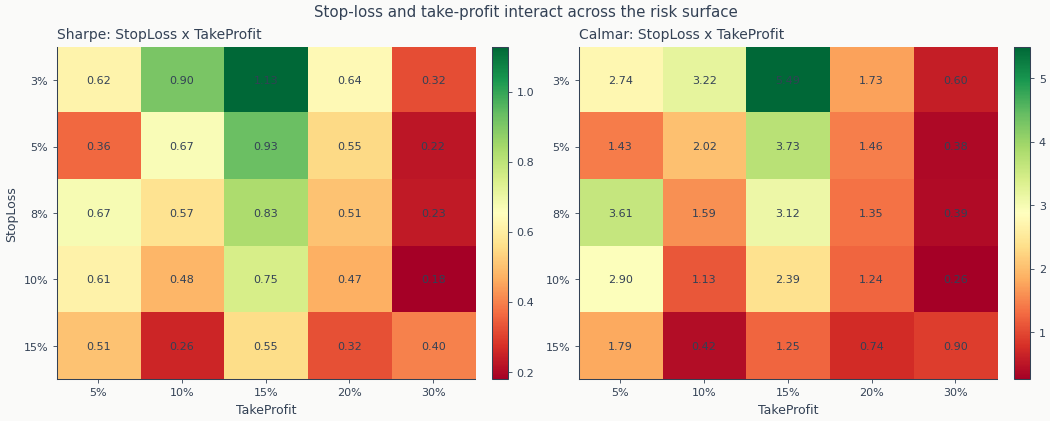


Best SL x TP by Calmar: SL=3%, TP=15% (Sharpe=1.127, Calmar=5.49)


In [20]:
fig_grid, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)
im0 = axes[0].imshow(sl_tp_sharpe, cmap="RdYlGn", aspect="auto")
axes[0].set_title("Sharpe: StopLoss x TakeProfit")
axes[0].set_xticks(range(len(tp_grid)), tp_labels)
axes[0].set_yticks(range(len(sl_grid)), sl_labels)
axes[0].set_xlabel("TakeProfit")
axes[0].set_ylabel("StopLoss")
for i in range(len(sl_grid)):
    for j in range(len(tp_grid)):
        axes[0].text(j, i, f"{sl_tp_sharpe[i, j]:.2f}", ha="center", va="center", fontsize=8)
im1 = axes[1].imshow(sl_tp_calmar, cmap="RdYlGn", aspect="auto")
axes[1].set_title("Calmar: StopLoss x TakeProfit")
axes[1].set_xticks(range(len(tp_grid)), tp_labels)
axes[1].set_yticks(range(len(sl_grid)), sl_labels)
axes[1].set_xlabel("TakeProfit")
for i in range(len(sl_grid)):
    for j in range(len(tp_grid)):
        axes[1].text(j, i, f"{sl_tp_calmar[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig_grid.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig_grid.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
fig_grid.suptitle("Stop-loss and take-profit interact across the risk surface")
plt.show()

# Persist SL x TP grid for the figure-19.7 publication script.
grid_rows = []
for i, sl in enumerate(sl_grid):
    for j, tp in enumerate(tp_grid):
        grid_rows.append(
            {
                "stop_loss": float(sl),
                "take_profit": float(tp),
                "sharpe": float(sl_tp_sharpe[i, j]),
                "calmar": float(sl_tp_calmar[i, j]),
            }
        )
pl.DataFrame(grid_rows).write_parquet(OUTPUT_DIR / "stoploss_takeprofit_grid.parquet")

# Best SL x TP combination
best_idx = np.unravel_index(sl_tp_calmar.argmax(), sl_tp_calmar.shape)
best_sl_tp = (sl_grid[best_idx[0]], tp_grid[best_idx[1]])
print(
    f"\nBest SL x TP by Calmar: SL={best_sl_tp[0]:.0%}, TP={best_sl_tp[1]:.0%} "
    f"(Sharpe={sl_tp_sharpe[best_idx]:.3f}, Calmar={sl_tp_calmar[best_idx]:.2f})"
)

**Interpretation**: The publication figure and the best-point readout provide the
calibration recommendation the chapter can cite directly.

In [21]:
# StopLoss x TrailingStop grid (5x5)
trail_grid = [0.02, 0.04, 0.06, 0.08, 0.10]

sl_trail_sharpe = np.zeros((len(sl_grid), len(trail_grid)))
sl_trail_calmar = np.zeros((len(sl_grid), len(trail_grid)))

print("Running SL x Trail grid (25 combinations)...")
for i, sl in enumerate(sl_grid):
    for j, trail in enumerate(trail_grid):
        rules = RuleChain([StopLoss(pct=sl), TrailingStop(pct=trail)])
        m = run_risk_sweep(
            prices_df,
            weight_dict,
            rules=rules,
            initial_cash=INITIAL_CASH,
            cadence_days=CADENCE_DAYS,
        )
        sl_trail_sharpe[i, j] = m["sharpe"]
        sl_trail_calmar[i, j] = m["calmar"]

Running SL x Trail grid (25 combinations)...


**Interpretation**: The SL x Trail grid tests whether dynamic exits preserve more
upside than fixed profit targets while still controlling drawdowns.

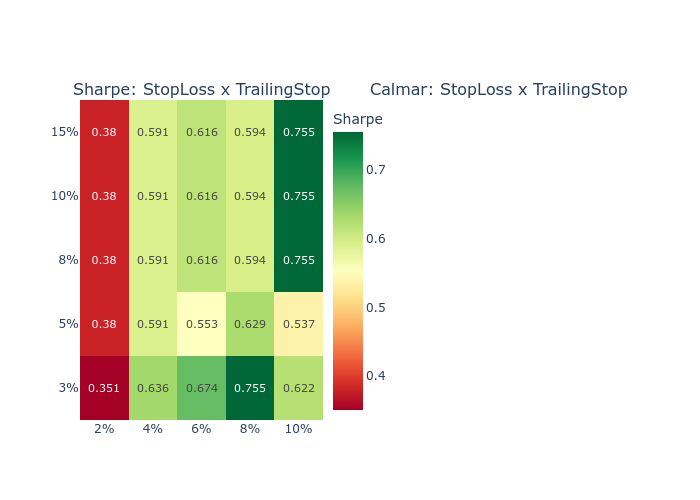

In [22]:
# Visualize SL x Trail heatmaps
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Sharpe: StopLoss x TrailingStop", "Calmar: StopLoss x TrailingStop"],
)

trail_labels = [f"{x:.0%}" for x in trail_grid]

fig.add_trace(
    go.Heatmap(
        z=sl_trail_sharpe,
        x=trail_labels,
        y=sl_labels,
        colorscale="RdYlGn",
        text=np.round(sl_trail_sharpe, 3),
        texttemplate="%{text}",
        textfont=dict(size=11),
        showscale=True,
        colorbar=dict(title="Sharpe", x=0.45),
    ),
    row=1,
    col=1,
)

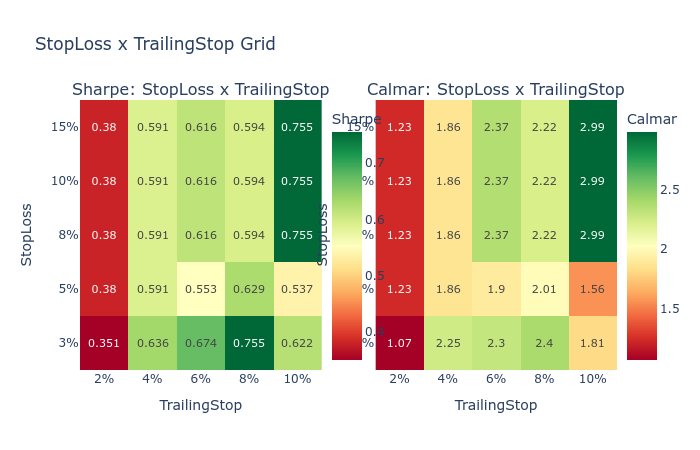

In [23]:
fig.add_trace(
    go.Heatmap(
        z=sl_trail_calmar,
        x=trail_labels,
        y=sl_labels,
        colorscale="RdYlGn",
        text=np.round(sl_trail_calmar, 2),
        texttemplate="%{text}",
        textfont=dict(size=11),
        showscale=True,
        colorbar=dict(title="Calmar", x=1.0),
    ),
    row=1,
    col=2,
)

fig.update_xaxes(title_text="TrailingStop", row=1, col=1)
fig.update_xaxes(title_text="TrailingStop", row=1, col=2)
fig.update_yaxes(title_text="StopLoss", row=1, col=1)
fig.update_yaxes(title_text="StopLoss", row=1, col=2)
fig.update_layout(height=450, title="StopLoss x TrailingStop Grid")
fig.show()

**Interpretation**: The trailing-stop surface shows whether dynamic exits create a
smoother frontier than fixed take-profit rules.

In [24]:
# Best SL x Trail combination
best_idx = np.unravel_index(sl_trail_calmar.argmax(), sl_trail_calmar.shape)
best_sl_trail = (sl_grid[best_idx[0]], trail_grid[best_idx[1]])
print(
    f"\nBest SL x Trail by Calmar: SL={best_sl_trail[0]:.0%}, Trail={best_sl_trail[1]:.0%} "
    f"(Sharpe={sl_trail_sharpe[best_idx]:.3f}, Calmar={sl_trail_calmar[best_idx]:.2f})"
)


Best SL x Trail by Calmar: SL=8%, Trail=10% (Sharpe=0.755, Calmar=2.99)


**Interpretation**: The 2D heatmaps show the interaction between rules.
The color gradient reveals the "safe zone" --- parameter combinations that
improve risk-adjusted returns without excessively reducing Sharpe. The Calmar
heatmap is particularly informative: it rewards configurations that protect
against drawdowns while preserving return.

## 4. MAE/MFE Calibration

Instead of grid search, we use the data itself to suggest stop and target
levels. Run the baseline to collect trade-level MAE/MFE statistics, then
use `MAEMFEAnalyzer.suggest_stop_loss(90)` and
`suggest_take_profit(75)` to find data-driven levels.

In [25]:
# Analyze baseline trades
if baseline["trades"]:
    mae_mfe = MAEMFEAnalyzer(baseline["trades"])

    print("=== MAE/MFE Analysis (Baseline Trades) ===")
    print(f"  Trades analyzed: {mae_mfe.num_trades}")
    print(f"  MAE mean:   {mae_mfe.mae_mean:.4f} ({mae_mfe.mae_mean:.2%})")
    print(f"  MAE median: {mae_mfe.mae_median:.4f} ({mae_mfe.mae_median:.2%})")
    print(f"  MFE mean:   {mae_mfe.mfe_mean:.4f} ({mae_mfe.mfe_mean:.2%})")
    print(f"  MFE median: {mae_mfe.mfe_median:.4f} ({mae_mfe.mfe_median:.2%})")
    print(f"  Edge ratio: {mae_mfe.edge_ratio:.2f}")
    print(f"  Efficiency: {mae_mfe.efficiency:.2%}")

    # Suggested levels
    suggested_sl = mae_mfe.suggest_stop_loss(percentile=90)
    suggested_tp = mae_mfe.suggest_take_profit(percentile=75)
    optimal = mae_mfe.optimal_exit_levels(stop_percentile=90, target_percentile=75)

    print(f"\n  Suggested StopLoss (90th pctl):   {suggested_sl:.4f} ({suggested_sl:.2%})")
    print(f"  Suggested TakeProfit (75th pctl):  {suggested_tp:.4f} ({suggested_tp:.2%})")
    print(f"  Risk/Reward ratio:                {optimal['risk_reward']:.2f}")
else:
    print("No trades in baseline --- cannot compute MAE/MFE")
    suggested_sl = -0.05
    suggested_tp = 0.10

=== MAE/MFE Analysis (Baseline Trades) ===
  Trades analyzed: 8
  MAE mean:   -0.1388 (-13.88%)
  MAE median: -0.0908 (-9.08%)
  MFE mean:   0.3268 (32.68%)
  MFE median: 0.1948 (19.48%)
  Edge ratio: 2.35
  Efficiency: 61.53%

  Suggested StopLoss (90th pctl):   -0.2599 (-25.99%)
  Suggested TakeProfit (75th pctl):  0.1605 (16.05%)
  Risk/Reward ratio:                0.62


**Interpretation**: The MAE/MFE summary turns realized trade paths into a data-driven
prior for stop and target placement. If the edge ratio is weak, the calibration
should be treated cautiously.

In [26]:
# MAE vs MFE scatter plot
if baseline["trades"]:
    dist = mae_mfe.distribution_data()
    pnls = [t.pnl_percent for t in baseline["trades"]]

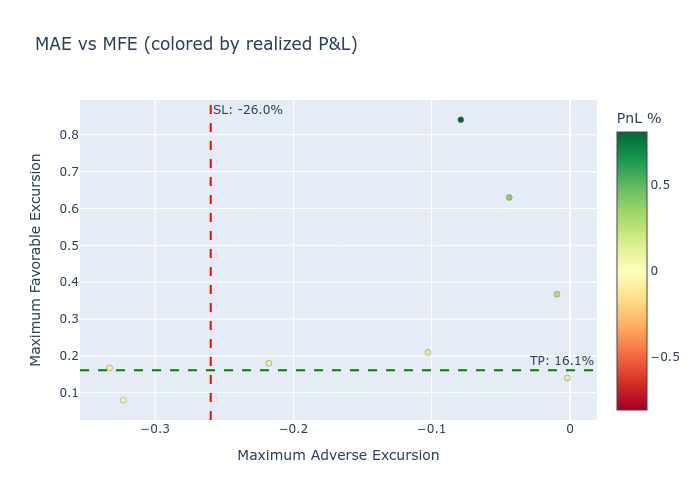

In [27]:
if baseline["trades"]:
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=dist["mae"],
            y=dist["mfe"],
            mode="markers",
            marker=dict(
                size=6,
                color=pnls,
                colorscale="RdYlGn",
                colorbar=dict(title="PnL %"),
                cmin=-max(abs(min(pnls)), abs(max(pnls))),
                cmax=max(abs(min(pnls)), abs(max(pnls))),
                line=dict(width=0.5, color="gray"),
            ),
            text=[f"PnL: {p:.2%}" for p in pnls],
            hovertemplate="MAE: %{x:.2%}<br>MFE: %{y:.2%}<br>%{text}",
        )
    )
    # Add suggested levels
    fig.add_vline(
        x=suggested_sl,
        line_dash="dash",
        line_color="red",
        annotation_text=f"SL: {suggested_sl:.1%}",
    )
    fig.add_hline(
        y=suggested_tp,
        line_dash="dash",
        line_color="green",
        annotation_text=f"TP: {suggested_tp:.1%}",
    )
    fig.update_layout(
        title="MAE vs MFE (colored by realized P&L)",
        xaxis_title="Maximum Adverse Excursion",
        yaxis_title="Maximum Favorable Excursion",
        height=500,
    )
    fig.show()

**Interpretation**: The scatter separates trades that needed room from trades that
never recovered. The suggested levels should cut through that cloud rather than sit
in an empty part of the path distribution.

In [28]:
# Run backtest with MAE/MFE-calibrated levels
calibrated_sl_pct = abs(suggested_sl)  # suggest_stop_loss returns negative
calibrated_tp_pct = abs(suggested_tp)

print(
    f"\nRunning MAE/MFE-calibrated backtest: SL={calibrated_sl_pct:.1%}, TP={calibrated_tp_pct:.1%}"
)
calibrated_rules = RuleChain(
    [
        StopLoss(pct=calibrated_sl_pct),
        TakeProfit(pct=calibrated_tp_pct),
    ]
)
calibrated = run_risk_sweep(
    prices_df,
    weight_dict,
    rules=calibrated_rules,
    initial_cash=INITIAL_CASH,
    cadence_days=CADENCE_DAYS,
)
print(
    f"  Sharpe={calibrated['sharpe']:.3f}  MaxDD={calibrated['max_dd']:.2%}  "
    f"Calmar={calibrated['calmar']:.2f}  Trades={calibrated['n_trades']}"
)


Running MAE/MFE-calibrated backtest: SL=26.0%, TP=16.1%
  Sharpe=0.416  MaxDD=-27.68%  Calmar=0.81  Trades=11


**Interpretation**: The calibrated backtest is the fairness check. If percentile-based
levels are materially worse than the grid surface, the excursion prior is too crude.

## 5. Comparison Table

All configurations ranked by Calmar ratio. The MAE/MFE-calibrated levels
are compared against the grid-optimal and baseline configurations.

In [29]:
comparison = {
    "Baseline (no rules)": baseline,
    f"Grid-optimal SL x TP ({best_sl_tp[0]:.0%}/{best_sl_tp[1]:.0%})": run_risk_sweep(
        prices_df,
        weight_dict,
        rules=RuleChain([StopLoss(pct=best_sl_tp[0]), TakeProfit(pct=best_sl_tp[1])]),
        initial_cash=INITIAL_CASH,
        cadence_days=CADENCE_DAYS,
    ),
    f"Grid-optimal SL x Trail ({best_sl_trail[0]:.0%}/{best_sl_trail[1]:.0%})": run_risk_sweep(
        prices_df,
        weight_dict,
        rules=RuleChain(
            [
                StopLoss(pct=best_sl_trail[0]),
                TrailingStop(pct=best_sl_trail[1]),
            ]
        ),
        initial_cash=INITIAL_CASH,
        cadence_days=CADENCE_DAYS,
    ),
    f"MAE/MFE-calibrated ({calibrated_sl_pct:.0%}/{calibrated_tp_pct:.0%})": calibrated,
}

ranked = sorted(comparison.items(), key=lambda x: x[1]["calmar"], reverse=True)
ranked_table = pl.DataFrame(
    {
        "Configuration": [name + (" ←" if "MAE/MFE" in name else "") for name, _ in ranked],
        "Sharpe": [round(m["sharpe"], 3) for _, m in ranked],
        "MaxDD": [f"{m['max_dd']:.2%}" for _, m in ranked],
        "Calmar": [round(m["calmar"], 2) for _, m in ranked],
        "Return": [f"{m['total_return']:.2%}" for _, m in ranked],
        "Trades": [m["n_trades"] for _, m in ranked],
        "WinRate": [f"{m['win_rate']:.1%}" for _, m in ranked],
    }
)
ranked_table

Configuration,Sharpe,MaxDD,Calmar,Return,Trades,WinRate
str,f64,str,f64,str,i64,str
"""Grid-optimal SL x TP (3%/15%)""",1.127,"""-5.48%""",5.49,"""30.09%""",12,"""58.3%"""
"""Grid-optimal SL x Trail (8%/10…",0.755,"""-11.82%""",2.99,"""35.32%""",11,"""72.7%"""
"""Baseline (no rules)""",0.585,"""-34.56%""",2.03,"""70.12%""",8,"""87.5%"""
"""MAE/MFE-calibrated (26%/16%) ←""",0.416,"""-27.68%""",0.81,"""22.45%""",11,"""72.7%"""


**Interpretation**: Ranked by Calmar, the grid-optimal SL×TP configuration
(3% SL / 15% TP) finishes first at 5.49, followed by the grid-optimal
SL×Trail (8%/10%) at 2.99, the no-rules baseline at 2.03, and the
MAE/MFE-calibrated configuration (26% SL / 16% TP) last at 0.81. Two findings
matter for §19.7. First, a targeted grid over the stop and take-profit axes
clearly improves risk-adjusted return over the baseline — the tight-stop /
moderate-take-profit corner (3%/15%) cuts max drawdown to ~5% while lifting
Sharpe above 1. Second, MAE/MFE percentile calibration is a cheap, data-driven
starting point but not a substitute for the sweep: realised excursions here
point to a wide stop (26%) and moderate target (16%) that underperform the
tuned grid. Use the calibration to seed the search, then sweep.

## Key Takeaways

1. **Sharpe surfaces are non-monotone in stop and take-profit width.**
   The stop-loss sweep traces a U-shape — Sharpe falls from 0.38 at a 2%
   stop to ~0.20 around 5%, then recovers to ~0.50 by 15% — with no level
   driving it negative on this panel. TP and TrailingStop show similar
   non-monotone shapes. Calibration is required — a tighter stop is not
   automatically a safer stop.
2. **The grid sweep beats MAE/MFE calibration by Calmar here.** The
   grid-optimal SL×TP (3%/15%) ranks first at Calmar 5.49, ahead of the
   no-rules baseline (2.03), while the MAE/MFE percentile levels (26%/16%)
   land last at 0.81. The realised-excursion percentiles give a fast prior,
   but on this panel they point too wide; a 25-cell grid still earns its keep.
3. **Position rules, not portfolio limits, are what you sweep.** Every
   surface in this notebook varies position-level stops and exits.
   Portfolio-level governance (`MaxDrawdownLimit`, `DailyLossLimit`) is
   a kill switch set by the risk mandate — not a parameter to optimize.
   See `10_ml4t_backtest_risk_demo` §3 and §19.8.

**Book reference**: §19.7 Adaptive Risk Controls (Figures 19.6 + 19.7).

**Next**: [`10_ml4t_backtest_risk_demo`](10_ml4t_backtest_risk_demo.ipynb)
documents the full `ml4t.backtest.risk` rule API used by these sweeps.